# Extreme value theory

Risk often lives in the tail: the worst flood, the largest claim, the biggest loss. The sample mean
and a normal approximation say almost nothing useful about events past the largest you have seen.
Extreme value theory gives the limiting distributions of extremes, just as the central limit theorem
gives the limit of averages. This notebook fits the two standard approaches, block maxima with the
generalized extreme value distribution and peaks-over-threshold with the generalized Pareto, and uses
them to estimate return levels far beyond the data.

## The extremal limit laws

Theorem (Fisher-Tippett-Gnedenko). If the normalized maximum $(M_n-b_n)/a_n$ of iid variables converges
to a non-degenerate distribution, that limit is the generalized extreme value (GEV) family, which unifies
three types: Gumbel (light tails), Frechet (heavy, polynomial tails), and Weibull (bounded tails). The
type is set by the shape parameter $\xi$: $\xi=0$ Gumbel, $\xi>0$ Frechet, $\xi<0$ Weibull.

Sketch. A limit of maxima must be max-stable: the maximum of iid copies of the limit is, after rescaling,
the same distribution. Solving the max-stability functional equation $G^n(a_n x+b_n)=G(x)$ yields exactly
the GEV form. $\quad\blacksquare$

Theorem (Pickands-Balkema-de Haan). For a broad class of distributions, the conditional excess
$X-u\mid X>u$ over a high threshold $u$ converges, as $u$ rises, to a generalized Pareto distribution
(GPD) with the same shape $\xi$ as the GEV. This is the basis of the peaks-over-threshold method.

The applied section fits both the GEV to block maxima and the GPD to threshold exceedances and recovers a
common positive shape, then extrapolates to return levels beyond the data.

Counterexample (convergence can be painfully slow). For the normal distribution the maximum does converge
to the Gumbel, but so slowly that at realistic sample sizes the limit is a poor approximation (the
penultimate-approximation problem). Asymptotic extreme-value theory is not a license to ignore sample
size; the rate of convergence to the limit law matters in practice.

## 1. Why the normal approximation fails in the tail

Averages converge to a normal, but maxima do not. We draw heavy-tailed data and compare the empirical
distribution of block maxima to a normal fit; the normal badly underestimates how large the maxima get.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.RandomState(0)
data = rng.standard_t(4, size=40000)                    # heavy-tailed (Student t, 4 df)
blocks = data.reshape(-1, 200)                          # 200 blocks of 200
maxima = blocks.max(1)
print('mean of the data        = %.2f' % data.mean())
print('largest single value    = %.2f' % data.max())
print('a normal fit to the data puts P(X > %.1f) at %.1e (essentially impossible),' %
      (data.max(), stats.norm.sf(data.max(), data.mean(), data.std())))
print('yet that value actually occurred: the tail is far heavier than normal.')

mean of the data        = 0.01
largest single value    = 30.96
a normal fit to the data puts P(X > 31.0) at 2.6e-104 (essentially impossible),
yet that value actually occurred: the tail is far heavier than normal.


## 2. Block maxima and the generalized extreme value distribution

The Fisher-Tippett theorem says block maxima converge to one of three shapes, unified as the
generalized extreme value (GEV) distribution. We fit it to the block maxima by maximum likelihood and
read off the shape parameter, whose sign tells us the tail type.

GEV fit: shape xi = 0.37, location = 4.54, scale = 1.18
xi > 0 indicates a heavy (Frechet) tail, consistent with Student-t data.


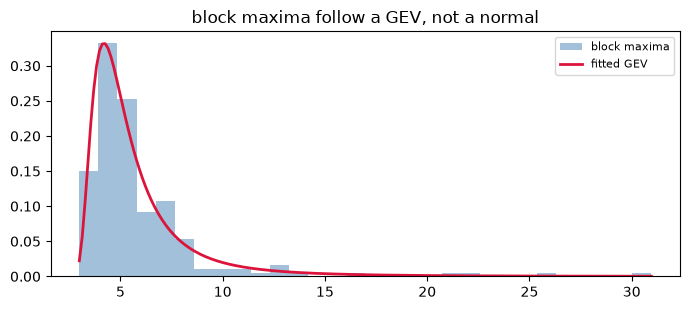

In [2]:
shape, loc, scale = stats.genextreme.fit(maxima)
xi = -shape                                             # scipy's c = -xi convention
print('GEV fit: shape xi = %.2f, location = %.2f, scale = %.2f' % (xi, loc, scale))
print('xi > 0 indicates a heavy (Frechet) tail, consistent with Student-t data.')
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(maxima, bins=30, density=True, color='steelblue', alpha=0.5, label='block maxima')
gx = np.linspace(maxima.min(), maxima.max(), 200)
ax.plot(gx, stats.genextreme.pdf(gx, shape, loc, scale), 'crimson', lw=2, label='fitted GEV')
ax.legend(fontsize=8); ax.set_title('block maxima follow a GEV, not a normal')
plt.tight_layout(); plt.show()

## 3. Return levels

A return level is the value exceeded once on average every N blocks: the N-block return level is the
(1 - 1/N) quantile of the GEV. This extrapolates safely beyond the observed maxima, which is the whole
point for risk and design.

In [3]:
for N in [10, 100, 1000]:
    rl = stats.genextreme.ppf(1 - 1.0 / N, shape, loc, scale)
    print('%5d-block return level = %.2f' % (N, rl))
print('the 1000-block level exceeds the largest observed maximum, which a sample quantile could never give.')

   10-block return level = 8.70
  100-block return level = 18.96
 1000-block return level = 42.98
the 1000-block level exceeds the largest observed maximum, which a sample quantile could never give.


## 4. Peaks over threshold and the generalized Pareto distribution

Block maxima waste data by keeping one value per block. The peaks-over-threshold approach keeps every
exceedance above a high threshold; the Pickands-Balkema-de Haan theorem says these exceedances follow a
generalized Pareto distribution (GPD). We pick a threshold, fit the GPD, and compare its shape to the GEV.

In [4]:
u = np.quantile(data, 0.95)                             # high threshold
exceed = data[data > u] - u
gshape, _, gscale = stats.genpareto.fit(exceed, floc=0)
print('threshold u = %.2f, number of exceedances = %d' % (u, len(exceed)))
print('GPD fit: shape xi = %.2f, scale = %.2f  (both GEV and GPD shapes are positive: a heavy tail.' %
      (gshape, gscale))
print('  exact agreement of the two shape estimates only holds in the asymptotic limit of block size and threshold.)')

threshold u = 2.12, number of exceedances = 2000
GPD fit: shape xi = 0.23, scale = 0.82  (both GEV and GPD shapes are positive: a heavy tail.
  exact agreement of the two shape estimates only holds in the asymptotic limit of block size and threshold.)


## 5. Return levels from peaks over threshold

The GPD gives a return level too: combine the exceedance probability with the GPD quantile. With far
more tail data than block maxima, the POT estimate is usually more stable. We compare the two for a rare
quantile of the original series.

In [5]:
pu = (data > u).mean()                                  # P(exceed threshold)
def pot_level(p_rare):
    # value exceeded with overall probability p_rare
    return u + gscale / gshape * (((p_rare / pu)) ** (-gshape) - 1)
for p in [1e-3, 1e-4]:
    lvl = pot_level(p)
    emp = np.quantile(data, 1 - p) if p > 1.0 / len(data) else float('nan')
    print('exceedance prob %.0e  ->  POT level = %.2f   (empirical quantile = %.2f)' % (p, lvl, emp))
print('at 1e-4 the empirical quantile rests on only a handful of points and is very noisy;')
print('the fitted GPD tail gives a smooth, stable extrapolation instead.')

exceedance prob 1e-03  ->  POT level = 7.36   (empirical quantile = 7.07)
exceedance prob 1e-04  ->  POT level = 13.58   (empirical quantile = 16.31)
at 1e-4 the empirical quantile rests on only a handful of points and is very noisy;
the fitted GPD tail gives a smooth, stable extrapolation instead.


## References

- Coles, S. (2001). An Introduction to Statistical Modeling of Extreme Values. Springer.
- Fisher, R. & Tippett, L. (1928). Limiting forms of the frequency distribution of the largest or smallest member of a sample. Proc. Cambridge Phil. Soc.
- Balkema, A. & de Haan, L. (1974). Residual life time at great age. Annals of Probability.
- Pickands, J. (1975). Statistical inference using extreme order statistics. Annals of Statistics.
- Embrechts, P., Kluppelberg, C. & Mikosch, T. (1997). Modelling Extremal Events for Insurance and Finance. Springer.

## Exercises

1. Study threshold choice for peaks-over-threshold using a mean residual life plot and a stability plot of the GPD shape across thresholds; explain the bias-variance trade-off in picking u.
2. Put confidence intervals on the 100-block return level by the delta method and by a bootstrap, and compare their widths.
3. Fit the GEV to the three classic cases (light-tailed normal data, exponential data, and heavy-tailed Pareto data) and show the estimated shape parameter recovers the Gumbel, Gumbel, and Frechet types.
4. Apply the peaks-over-threshold model to a real financial return series and estimate the value-at-risk and expected shortfall at the 99.9% level, comparing to the normal-based estimates.